# Notebook 10 — Linear Algebra for Statistics — Student version

*Quantitative Methods in Neuroscience, Master in Neuroscience, University of Geneva (2026-27)*

This is the practical companion to **Lecture 10 — Linear Algebra for Statistics**. The lecture showed how the statistical tools you already know — variance, covariance, regression — can be written compactly in matrix form, and introduced the concepts of *basis change*, *eigenvalues/eigenvectors*, and *diagonalization* that are essential for dimensionality reduction and population analysis in neuroscience.

### By the end of this notebook you will be able to:
- Compute the **covariance matrix** of a dataset and interpret it geometrically.
- Express **linear regression** in matrix form and solve it with `np.linalg.lstsq`.
- Compute **eigenvalues and eigenvectors** of a symmetric matrix and connect them to the covariance structure of the data.
- Perform a **change of basis** (rotate data into a new coordinate system) and see how it decorrelates the data.
- Compute and interpret the **trace** and **determinant** as basis-invariant scalars.
- Apply these tools to a **real EEG dataset** and read structure directly off the covariance matrix.

### Table of contents
1. [Setup](#section-1)
2. [Covariance in matrix form](#section-2)
3. [Linear regression in matrix form](#section-3)
4. [Trace and determinant as invariants](#section-4)
5. [Eigenvalues, eigenvectors, and diagonalization](#section-5)
6. [Change of basis](#section-6)
7. [Looking ahead: from diagonalization to PCA](#section-7)
8. [Lego-style exercises](#section-8)
9. [Covariance and regression on real EEG data](#section-9)

**How to read this notebook.** Markdown cells explain *why* we do something and the concept behind it. Code cells implement it. Look out for **`▶ Task`** boxes — those are the exercises. Each task carries a **difficulty tag**:

| Tag | Meaning | Typical student action |
|-----|---------|------------------------|
| 👨🏻‍🏫 ⭐️ | Essential for all students. | Run, understand, and slightly modify the provided code. |
| 🧐 ⭐️⭐️ | Intermediate extension. | Repair a small bug, complete missing lines, or write a short function. |
| 😎 ⭐️⭐️⭐️ | Optional challenge. | Build a fuller workflow, compare methods, or extend the analysis. |

If you are stuck, ask the TAs or use the course GPT bot: https://chatgpt.com/g/g-69fc9bfc9a748191a912a124800d9254-qmn-teaching-assistant-bot


<a id="section-1"></a>
## 1. Setup

Make sure the `qmn` conda environment is active and selected as the kernel (top-right corner of VS Code).


In [1]:
# --- Import the scientific Python stack
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from cycler import cycler
from ipywidgets import interact
import ipywidgets as widgets

plt.rcParams.update({
    "figure.figsize": (6, 5),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
    "axes.prop_cycle": cycler(color=[
        "#1f77b4",   # blue
        "#ff7f0e",   # orange
        "#5b2c83",   # purple
        "#2ca02c",   # green
    ]),
})

rng = np.random.default_rng(42)   # reproducible random numbers
print(f"NumPy version: {np.__version__}")
print("Setup complete.")


NumPy version: 2.4.3
Setup complete.


<a id="section-2"></a>
## 2. Covariance in matrix form

### From scalar variance to the covariance matrix

You may have computed the variance of a single variable before:

$$
\text{Var}(x) = \frac{1}{n-1} \sum_{i=1}^n (x_i - \bar{x})^2
$$

When we have **multiple variables** (e.g. the firing rates of $p$ neurons recorded simultaneously), we care not only about how much each variable varies, but also about how pairs of variables *co-vary*. The **covariance matrix** $\Sigma$ captures all of this at once:

$$
\Sigma_{jk} = \text{Cov}(x_j, x_k) = \frac{1}{n-1} \sum_{i=1}^n (x_{ij} - \bar{x}_j)(x_{ik} - \bar{x}_k)
$$

In matrix form, if $X$ is the $(n \times p)$ data matrix with **zero-mean columns** (i.e. each column already has mean subtracted):

$$
\Sigma = \frac{1}{n-1}\, X^\top X \;\in\; \mathbb{R}^{p \times p}
$$

Note that $\Sigma$ is always **symmetric** ($\Sigma = \Sigma^\top$) and **positive semi-definite**.


In [2]:
# --- Simulate a 2-neuron dataset with known covariance structure
n = 300   # number of data points (trials)
p = 2     # number of variables (neurons)

# True covariance matrix: neurons have different variances and are positively correlated
Sigma_true = np.array([[4.0, 1.8],
                        [1.8, 1.0]])

# Draw samples from a zero-mean bivariate Gaussian
L = np.linalg.cholesky(Sigma_true)   # Cholesky factorisation: Sigma = L L^T
X_raw = rng.standard_normal((n, p)) @ L.T   # shape (n, 2)

print("X_raw shape:", X_raw.shape)   # (300, 2)
print("Column means (should be ~0):", X_raw.mean(axis=0).round(3))


X_raw shape: (300, 2)
Column means (should be ~0): [-0.045 -0.033]


In [3]:
# --- Compute the sample covariance matrix two ways

# Method 1: NumPy built-in (rowvar=False: each column is one variable)
Sigma_np = np.cov(X_raw, rowvar=False)

# Method 2: Manual matrix formula  Sigma = X^T X / (n-1)
X_centered = X_raw - X_raw.mean(axis=0)     # subtract column means
Sigma_manual = X_centered.T @ X_centered / (n - 1)

print("True covariance matrix:\n", Sigma_true)
print("\nSample (np.cov):\n", Sigma_np.round(3))
print("\nSample (manual X^T X / (n-1)):\n", Sigma_manual.round(3))
print("\nAre both methods equal:", np.allclose(Sigma_np, Sigma_manual))


True covariance matrix:
 [[4.  1.8]
 [1.8 1. ]]

Sample (np.cov):
 [[3.98  1.913]
 [1.913 1.087]]

Sample (manual X^T X / (n-1)):
 [[3.98  1.913]
 [1.913 1.087]]

Are both methods equal: True


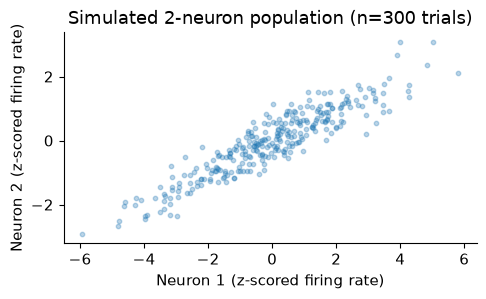

Correlation coefficient: 0.919


In [4]:
# --- Visualize the data and the covariance
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(X_raw[:, 0], X_raw[:, 1], alpha=0.3, s=10)
ax.set_xlabel("Neuron 1 (z-scored firing rate)")
ax.set_ylabel("Neuron 2 (z-scored firing rate)")
ax.set_title("Simulated 2-neuron population (n=300 trials)")
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

print(f"Correlation coefficient: {Sigma_np[0,1] / np.sqrt(Sigma_np[0,0] * Sigma_np[1,1]):.3f}")


> **▶ Task 2.1 — 👨🏻‍🏫 ⭐️ Properties of the covariance matrix.**
>
> Use `Sigma_np` to verify the following **numerically**:
>
> 1. $\Sigma$ is **symmetric**: `Sigma == Sigma.T`
> 2. All eigenvalues of $\Sigma$ are **non-negative** (positive semi-definite). Compute `np.linalg.eigvalsh(Sigma)` and inspect.
> 3. The **diagonal entries** equal the variances of each column: compare `Sigma[0,0]` with `np.var(X_raw[:,0], ddof=1)`.
>
> Why is positive semi-definiteness of a covariance matrix guaranteed? Write your answer as a comment.


In [5]:
# TODO 2.1 — verify covariance matrix properties

# 1. Symmetry
# YOUR CODE HERE

# 2. Positive semi-definiteness
eigvals = ___   # YOUR CODE HERE
# YOUR CODE HERE
# YOUR CODE HERE

# 3. Diagonal = variances
# YOUR CODE HERE
# YOUR CODE HERE

# Why positive semi-definite?
# Because for any vector v: v^T Sigma v = (1/(n-1)) * ||X_centered @ v||^2 >= 0.
# YOUR CODE HERE


<a id="section-3"></a>
## 3. Linear regression in matrix form

In the lecture you saw that ordinary least-squares (OLS) regression can be expressed entirely in matrix notation. 

Given a design matrix $X \in \mathbb{R}^{n \times p}$ and a target vector $\mathbf{y} \in \mathbb{R}^n$, the OLS solution that minimizes $\|\mathbf{y} - X\boldsymbol{\beta}\|^2$ is:

$$
\hat{\boldsymbol{\beta}} = (X^\top X)^{-1} X^\top \mathbf{y} = X^+ \mathbf{y}
$$

This is exactly the pseudo-inverse from Notebook 9. The *fitted values* are the **projection** of $\mathbf{y}$ onto the column space of $X$:

$$
\hat{\mathbf{y}} = X \hat{\boldsymbol{\beta}} = X(X^\top X)^{-1} X^\top \mathbf{y} = H \mathbf{y}
$$

where $H = X(X^\top X)^{-1} X^\top$ is called the **hat matrix** (it "puts a hat on" $\mathbf{y}$).

**Neuroscience context.** OLS regression is the backbone of most neural data analysis: predicting a neuron's firing rate from a stimulus or behaviour variable, fitting a general linear model (GLM) to BOLD signals in fMRI, decoding behaviour from population activity.


Text(0, 0.5, 'Observation (y)')

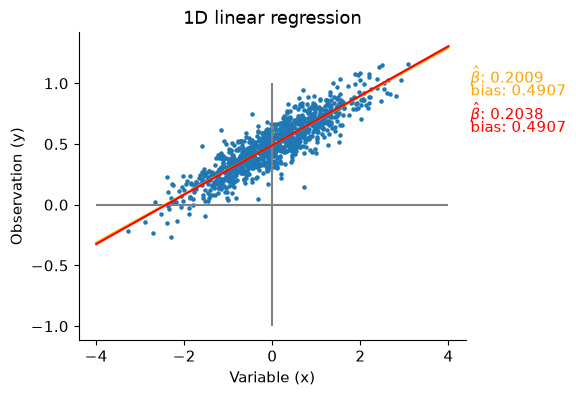

In [6]:
# starting with 1D variable:
rng2 = np.random.default_rng(7)

n_obs = 1000
x = np.random.normal(0, 1, n_obs)
true_beta = 0.2
true_bias = 0.5
noise = np.random.normal(0, .1, n_obs)
y = x * true_beta + noise + true_bias


estimated_beta = np.sum(((x - np.mean(x)) * (y - np.mean(y)))/np.sum((x - np.mean(x))**2))
estimated_bias = np.mean(y) - estimated_beta * np.mean(x)

estimated_beta_ = np.sum(x * y)/np.sum(x**2)
estimated_bias_ = np.mean(y) - estimated_beta_ * np.mean(x)

# drawing the slope and bias:
x_range = np.linspace(-4, 4, n_obs)
y_line = estimated_beta * x_range + estimated_bias
y_line_ = estimated_beta_ * x_range + estimated_bias_
fig, ax = plt.subplots(figsize=(5, 4))
ax.set_title('1D linear regression')
ax.vlines(0, -1, 1, color='gray')
ax.hlines(0, -4, 4, color='gray')
ax.scatter(x, y, s = 5)
ax.plot(x_range, y_line, color='orange')
ax.plot(x_range, y_line_, color='red')
ax.text(x=4.5, y=1, s=rf"$\hat\beta$: {estimated_beta:.4}", color='orange')
ax.text(x=4.5, y=.9, s=rf"bias: {estimated_bias:.4}", color='orange')

ax.text(x=4.5, y=1 - .3, s=rf"$\hat\beta$: {estimated_beta_:.4}", color='red')
ax.text(x=4.5, y=1- .4, s=rf"bias: {estimated_bias_:.4}", color='red')

ax.set_xlabel('Variable (x)')
ax.set_ylabel('Observation (y)')

In [7]:
# Toy data: y = theta*x + b + noise
rng = np.random.default_rng(0)
n = 200
theta_true = 2.5
b_true = -1.0
sigma = 0.5

x = rng.uniform(-3, 3, size=n)
noise = rng.normal(0, sigma, size=n)
y = theta_true * x + b_true + noise

# --- Fit A: WRONG model (slope-only, assumes intercept = 0) ---
# y ≈ theta * x
theta_hat_slope_only = (x @ y) / (x @ x)

# --- Fit B: Correct model (slope + intercept) via least squares ---
# y ≈ theta*x + b
X = np.column_stack([x, np.ones_like(x)])
(theta_hat, b_hat), *_ = np.linalg.lstsq(X, y, rcond=None)

print(f"True theta: {theta_true:.4f}, true bias b: {b_true:.4f}")
print(f"Slope-only fit: theta_hat = {theta_hat_slope_only:.4f} (biased if b_true != 0)")
print(f"Slope+intercept fit: theta_hat = {theta_hat:.4f}, b_hat = {b_hat:.4f}")

# Optional: quick sanity check on predictions
y_pred_slope_only = theta_hat_slope_only * x
y_pred_full = theta_hat * x + b_hat

mse_slope_only = np.mean((y - y_pred_slope_only)**2)
mse_full = np.mean((y - y_pred_full)**2)

print(f"MSE slope-only: {mse_slope_only:.4f}")
print(f"MSE slope+intercept: {mse_full:.4f}")

True theta: 2.5000, true bias b: -1.0000
Slope-only fit: theta_hat = 2.4046 (biased if b_true != 0)
Slope+intercept fit: theta_hat = 2.4789, b_hat = -1.0397
MSE slope-only: 1.3231
MSE slope+intercept: 0.2605


> **▶ Task 3.1 — 🧐 ⭐️ Sample size and noise.**
>
> The cell below fits the simple 1-D model $y = \theta x + b + \varepsilon$ and is written so the two things you will vary are **global parameters at the top**: `N_OBS` (number of samples) and `NOISE_SIGMA` (noise standard deviation).
>
> 1. Try `N_OBS` = 20, 200, 2000, 20000. How close does the estimated slope $\hat\theta$ get to the true value as the sample size grows?
> 2. Reset `N_OBS = 200` and try `NOISE_SIGMA` = 0.01, 0.05, 0.1, 0.5. How does the noise level affect the estimate and the scatter around the fitted line?
>
> Write what you observe in the answer cell below.

N_OBS = 200,  NOISE_SIGMA = 0.1
true  slope = 0.200,  estimated slope = 0.202
true  bias  = 0.500,  estimated bias  = 0.492


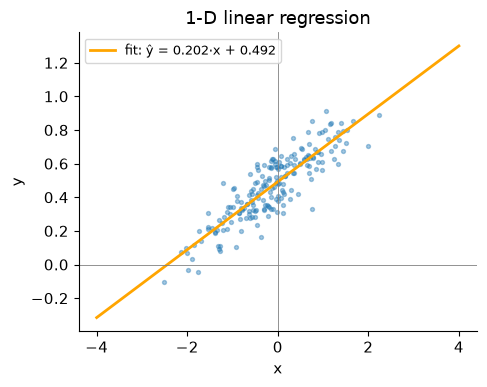

In [8]:
# --- Sample-size / noise playground  (Task 3.1)
# Two knobs to experiment with:
N_OBS       = 200      # <- try 20, 200, 2000, 20000
NOISE_SIGMA = 0.1      # <- try 0.01, 0.05, 0.1, 0.5

rng_play = np.random.default_rng(7)
true_beta = 0.2
true_bias = 0.5

x = rng_play.normal(0, 1, N_OBS)
noise = rng_play.normal(0, NOISE_SIGMA, N_OBS)
y = true_beta * x + true_bias + noise

# Closed-form OLS estimates (slope + intercept)
beta_hat = np.sum((x - x.mean()) * (y - y.mean())) / np.sum((x - x.mean())**2)
bias_hat = y.mean() - beta_hat * x.mean()

print(f"N_OBS = {N_OBS},  NOISE_SIGMA = {NOISE_SIGMA}")
print(f"true  slope = {true_beta:.3f},  estimated slope = {beta_hat:.3f}")
print(f"true  bias  = {true_bias:.3f},  estimated bias  = {bias_hat:.3f}")

# Plot data + fitted line
x_range = np.linspace(-4, 4, 200)
fig, ax = plt.subplots(figsize=(5, 4))
ax.scatter(x, y, s=8, alpha=0.4)
ax.plot(x_range, beta_hat * x_range + bias_hat, color='orange', lw=2,
        label=f'fit: ŷ = {beta_hat:.3f}·x + {bias_hat:.3f}')
ax.axhline(0, color='gray', lw=0.6); ax.axvline(0, color='gray', lw=0.6)
ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_title('1-D linear regression')
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()


> **✏️ Your answer (Task 3.1).**
>
> *Effect of increasing `N_OBS`:*  … (double-click to edit)
>
> *Effect of changing `NOISE_SIGMA`:*  …

Design matrix X_reg shape: (200, 3)
Target y_rt   shape: (200,)
True beta        : [ 0.7  -0.3  -0.02]
OLS (normal eq.) : [ 0.705  -0.327  -0.0219]
OLS (lstsq)      : [ 0.705  -0.327  -0.0219]
Both match: True


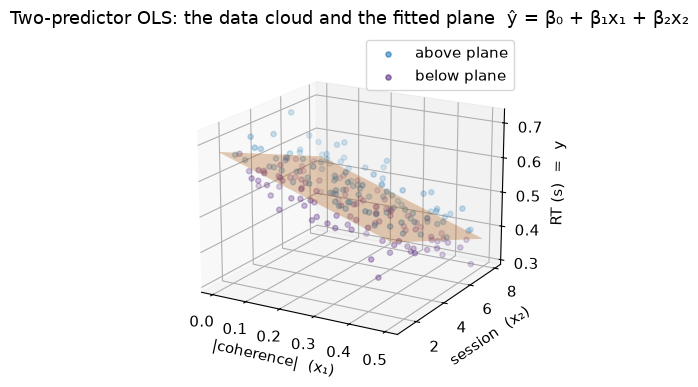

In [9]:
# --- Simulate a regression problem with TWO predictors → a fitted plane in 3D
# With two predictors x1, x2 the model  ŷ = β0 + β1·x1 + β2·x2  is a PLANE:
# a flat sheet floating over the (x1, x2) floor. OLS finds the plane that sits
# as close as possible to the cloud of observed points (least squares in the
# vertical direction).

n_obs = 200

# Two continuous predictors, kept continuous so the plane is easy to see
abs_coherence = rng2.uniform(0.0, 0.5, n_obs)   # x1: stimulus difficulty (0 = hard, 0.5 = easy)
session       = rng2.uniform(1.0, 8.0, n_obs)   # x2: training session

# True relationship: RT decreases with |coherence| and with session number
beta_true = np.array([0.70,   # intercept
                      -0.30,  # effect of |coherence|
                      -0.02]) # effect of session

X_reg = np.column_stack([
    np.ones(n_obs),   # intercept column
    abs_coherence,    # x1
    session,          # x2
])
noise_sigma = 0.05
y_rt = X_reg @ beta_true + rng2.normal(0, noise_sigma, n_obs)

print("Design matrix X_reg shape:", X_reg.shape)   # (200, 3)
print("Target y_rt   shape:", y_rt.shape)           # (200,)


# --- OLS via the normal equations  beta = (X^T X)^{-1} X^T y
XtX = X_reg.T @ X_reg                       # (3, 3)
Xty = X_reg.T @ y_rt                        # (3,)
beta_hat = np.linalg.solve(XtX, Xty)        # numerically stable inversion

# np.linalg.lstsq is even more convenient and numerically robust
beta_lstsq, _, _, _ = np.linalg.lstsq(X_reg, y_rt, rcond=None)

print("True beta        :", beta_true)
print("OLS (normal eq.) :", beta_hat.round(4))
print("OLS (lstsq)      :", beta_lstsq.round(4))
print("Both match:", np.allclose(beta_hat, beta_lstsq))


# --- Visualise: the data cloud in 3D and the fitted regression plane
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (registers the 3d projection)

# Build the plane ŷ = β0 + β1·x1 + β2·x2 over a grid of (x1, x2)
x1_grid = np.linspace(abs_coherence.min(), abs_coherence.max(), 12)
x2_grid = np.linspace(session.min(),       session.max(),       12)
X1, X2  = np.meshgrid(x1_grid, x2_grid)
Y_plane = beta_hat[0] + beta_hat[1] * X1 + beta_hat[2] * X2

fig = plt.figure(figsize=(5, 4))
ax = fig.add_subplot(111, projection="3d")

# Fitted plane (semi-transparent sheet)
ax.plot_surface(X1, X2, Y_plane, alpha=0.30, color="#ff7f0e", edgecolor="none")

# Observed data points, coloured by whether they sit above/below the plane
y_fit_at_point = beta_hat[0] + beta_hat[1] * abs_coherence + beta_hat[2] * session
above = y_rt >= y_fit_at_point
ax.scatter(abs_coherence[above], session[above], y_rt[above],
           s=14, color="#1f77b4", alpha=0.6, label="above plane")
ax.scatter(abs_coherence[~above], session[~above], y_rt[~above],
           s=14, color="#5b2c83", alpha=0.6, label="below plane")

ax.set_xlabel("|coherence|  (x₁)")
ax.set_ylabel("session  (x₂)")
ax.set_zlabel("RT (s)  =  y")
ax.set_title("Two-predictor OLS: the data cloud and the fitted plane  ŷ = β₀ + β₁x₁ + β₂x₂")
ax.view_init(elev=18, azim=-60)   # a viewing angle where the plane reads clearly
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

R² = 0.665


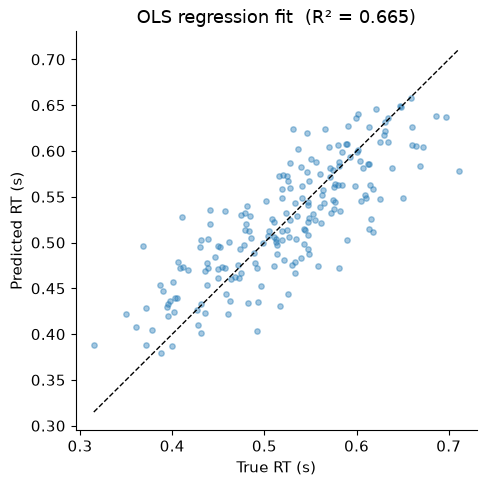

In [10]:
# --- R-squared: fraction of variance explained
y_hat = X_reg @ beta_hat
ss_res = np.sum((y_rt - y_hat) ** 2)
ss_tot = np.sum((y_rt - y_rt.mean()) ** 2)
R2 = 1.0 - ss_res / ss_tot
print(f"R² = {R2:.3f}")

# Plot: predicted vs actual
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(y_rt, y_hat, alpha=0.4, s=15)
lo, hi = y_rt.min(), y_rt.max()
ax.plot([lo, hi], [lo, hi], "k--", lw=1)
ax.set_xlabel("True RT (s)")
ax.set_ylabel("Predicted RT (s)")
ax.set_title(f"OLS regression fit  (R² = {R2:.3f})")
plt.tight_layout()
plt.show()


> **▶ Task 3.2 — 🧐 ⭐️⭐️ The hat matrix and projections.**
>
> The hat matrix $H = X(X^\top X)^{-1}X^\top$ is a projection matrix onto the column space of $X$. Projection matrices have two special properties:
>
> 1. **Idempotence**: $H^2 = H$ (applying the projection twice gives the same result as once).
> 2. **Symmetry**: $H = H^\top$.
>
> Complete the code below to:
> - Compute `H` from `X_reg` (use the formula above; do **not** use `np.linalg.pinv` — compute the inverse explicitly via `np.linalg.solve`).
> - Verify that `H @ H` is close to `H`.
> - Verify that `H == H.T`.
> - Confirm that `H @ y_rt` reproduces `y_hat` computed earlier.


In [11]:
# TODO 3.2 — compute the hat matrix and verify its properties
# H = X (X^T X)^{-1} X^T

# Step 1: solve (X^T X) C = X^T to get C = (X^T X)^{-1} X^T  (shape 3 x 200)
C = ___   # YOUR CODE HERE

# Step 2: H = X C  (shape 200 x 200)
H = ___   # YOUR CODE HERE

# Verify idempotence
# YOUR CODE HERE

# Verify symmetry
# YOUR CODE HERE

# Verify H y == y_hat
# YOUR CODE HERE

<a id="section-4"></a>
## 4. Trace and determinant as invariants

The lecture introduced two scalar quantities that summarize a matrix and, crucially, **do not change when you change the basis**.

### Trace

The **trace** is the sum of the diagonal elements:

$$
\text{tr}(A) = \sum_i A_{ii}
$$

For a covariance matrix, the trace equals the **total variance** across all variables (the sum of individual variances). It is invariant under orthogonal basis changes.

### Determinant

The **determinant** measures the *volume scaling factor* of the linear transformation. For a $2 \times 2$ matrix $\left(\begin{smallmatrix}a & b \\ c & d\end{smallmatrix}\right)$, $\det = ad - bc$. Key properties:

- $\det(AB) = \det(A)\det(B)$
- $\det(A^{-1}) = 1 / \det(A)$
- $\det = 0 \Leftrightarrow$ matrix is **singular** (not invertible)
- For a covariance matrix: $\det(\Sigma)$ measures *generalized variance* (the volume of the covariance ellipsoid).

**Both** the trace and the determinant equal the sum and product of the eigenvalues, respectively:

$$
\text{tr}(A) = \sum_i \lambda_i, \qquad \det(A) = \prod_i \lambda_i
$$

> **▶ Task 3.2 — 🧐 ⭐️ Trace and determinant.**
>
> Show these properties in a small $2 \times 2$ matrix
> $$
\text{tr}(A) = \sum_i \lambda_i, \qquad \det(A) = \prod_i \lambda_i
$$


In [12]:
# --- Trace and determinant
Sigma = Sigma_np   # 2x2 sample covariance computed in Section 2

tr  = np.trace(Sigma)
det = np.linalg.det(Sigma)

print("Covariance matrix:\n", Sigma.round(3))
print(f"\ntrace(Sigma) = {tr:.4f}  (= sum of variances = {Sigma[0,0]+Sigma[1,1]:.4f})")
print(f"det(Sigma)   = {det:.6f}")


Covariance matrix:
 [[3.98  1.913]
 [1.913 1.087]]

trace(Sigma) = 5.0677  (= sum of variances = 5.0677)
det(Sigma)   = 0.669349


In [13]:
# --- Eigenvalues relate to trace and determinant
eigvals = np.linalg.eigvalsh(Sigma)   # eigenvalues of a symmetric matrix
print("Eigenvalues:", eigvals.round(4))
print(f"Sum of eigenvalues   = {eigvals.sum():.4f}  vs  trace = {tr:.4f}")
print(f"Product of eigenvals = {eigvals.prod():.6f}  vs  det   = {det:.6f}")


Eigenvalues: [0.1357 4.932 ]
Sum of eigenvalues   = 5.0677  vs  trace = 5.0677
Product of eigenvals = 0.669349  vs  det   = 0.669349


In [14]:
# --- Invariance under orthogonal basis change
# Any orthogonal matrix Q (Q^T Q = I) defines a rotation / reflection
theta = np.pi / 6   # 30-degree rotation
Q = np.array([[np.cos(theta), -np.sin(theta)],
              [np.sin(theta),  np.cos(theta)]])

Sigma_rotated = Q @ Sigma @ Q.T   # covariance in the rotated basis

print("Original Sigma  trace:", np.trace(Sigma).round(6),
      " det:", np.linalg.det(Sigma).round(6))
print("Rotated  Sigma  trace:", np.trace(Sigma_rotated).round(6),
      " det:", np.linalg.det(Sigma_rotated).round(6))
print("Trace invariant :", np.isclose(np.trace(Sigma), np.trace(Sigma_rotated)))
print("Det   invariant :", np.isclose(np.linalg.det(Sigma), np.linalg.det(Sigma_rotated)))


Original Sigma  trace: 5.067729  det: 0.669349
Rotated  Sigma  trace: 5.067729  det: 0.669349
Trace invariant : True
Det   invariant : True


> **▶ Task 4.1 — 👨🏻‍🏫 ⭐️ When is the determinant zero?**
>
> The determinant is zero when the matrix is *singular* — i.e. when its columns are linearly dependent. This happens in practice when you include **redundant predictors** in a regression (a problem called *perfect multicollinearity*).
>
> 1. Create a $3 \times 3$ matrix `A_sing` where the third column is exactly twice the first column.
> 2. Compute `np.linalg.det(A_sing)`. What do you get?
> 3. Try to compute `np.linalg.inv(A_sing)`. What error or warning do you get?
> 4. In your own words: what does this mean for OLS regression when two predictors are perfectly correlated?


In [15]:
# TODO 4.1 — singular matrix and its determinant
A_sing = np.array([[1.0, 2.0, 2.0],   # col 3 = 2 * col 1  # TO BE MODIFIED by student
                   [3.0, 4.0, 6.0],
                   [5.0, 6.0, 10.0]])

# YOUR CODE HERE

# Try the inverse — it will produce numerically unstable / garbage results
# (NumPy may not raise an error; check the output carefully)
try:
    inv_sing = ___   # YOUR CODE HERE
    # YOUR CODE HERE
    # YOUR CODE HERE
except np.linalg.LinAlgError as e:
    print("LinAlgError:", e)


> **✏️ Your answer (Task 4.1).**
>
> *What does det = 0 mean for the columns of the matrix?*  … (double-click to edit)
>
> *Why does OLS fail when two predictors are perfectly correlated?*  … (double-click to edit)


<a id="section-5"></a>
## 5. Eigenvalues, eigenvectors, and diagonalization

An **eigenvector** $\mathbf{v}$ of a matrix $A$ is a non-zero vector that is only *scaled* (not rotated) by $A$:

$$
A \mathbf{v} = \lambda \mathbf{v}
$$

The scalar $\lambda$ is the corresponding **eigenvalue** — it tells you by *how much* the vector is stretched or compressed.

For a **symmetric matrix** (such as a covariance matrix):
- All eigenvalues are **real**.
- Eigenvectors corresponding to distinct eigenvalues are **orthogonal**.
- The matrix can be **diagonalized** as $A = Q \Lambda Q^\top$, where $Q$ is the orthogonal matrix of eigenvectors (columns) and $\Lambda = \text{diag}(\lambda_1, \ldots, \lambda_p)$.

NumPy provides two functions:
- `np.linalg.eig(A)` — general (non-symmetric) matrices
- `np.linalg.eigh(A)` — symmetric matrices (more accurate, eigenvalues returned in ascending order)


> **Note.** This section introduces eigenvalues and eigenvectors *hands-on*, building the intuition (an eigenvector is a direction the matrix only stretches; its eigenvalue is the stretch factor) and connecting them directly to the covariance structure of data. Because the concept is developed here in the practical, the lecture can treat the formal definition briefly and lean on this notebook for the geometric picture.

In [16]:
# --- Eigendecomposition of the sample covariance matrix
eigvals, eigvecs = np.linalg.eigh(Sigma)   # eigenvectors are COLUMNS of eigvecs

print("Eigenvalues  λ :", eigvals.round(4))
print("Eigenvectors (columns):\n", eigvecs.round(4))
print("\nAre eigenvectors orthogonal? Q^T Q =\n", (eigvecs.T @ eigvecs).round(10))


Eigenvalues  λ : [0.1357 4.932 ]
Eigenvectors (columns):
 [[ 0.4454 -0.8953]
 [-0.8953 -0.4454]]

Are eigenvectors orthogonal? Q^T Q =
 [[ 1. -0.]
 [-0.  1.]]


In [17]:
# --- Verify the eigenvector equation: A v = lambda v
for i in range(len(eigvals)):
    lhs = Sigma @ eigvecs[:, i]              # A v
    rhs = eigvals[i] * eigvecs[:, i]         # lambda * v
    print(f"λ{i+1}: A v = {lhs.round(4)},  λv = {rhs.round(4)},  equal: {np.allclose(lhs, rhs)}")


λ1: A v = [ 0.0605 -0.1215],  λv = [ 0.0605 -0.1215],  equal: True
λ2: A v = [-4.4157 -2.1969],  λv = [-4.4157 -2.1969],  equal: True


In [18]:
# --- Diagonalization: A = Q Lambda Q^T
Q   = eigvecs
Lam = np.diag(eigvals)
Sigma_reconstructed = Q @ Lam @ Q.T

print("Original Sigma:\n", Sigma.round(4))
print("Q @ Lambda @ Q^T:\n", Sigma_reconstructed.round(4))
print("Match:", np.allclose(Sigma, Sigma_reconstructed))


Original Sigma:
 [[3.9803 1.9128]
 [1.9128 1.0874]]
Q @ Lambda @ Q^T:
 [[3.9803 1.9128]
 [1.9128 1.0874]]
Match: True


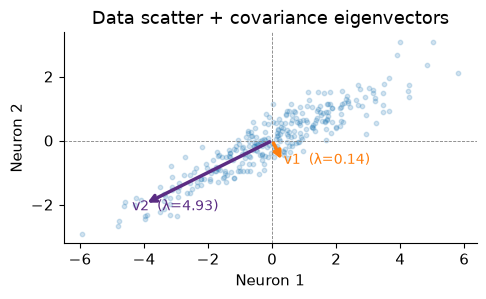

In [19]:
# --- Visualize eigenvectors on the scatter plot
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(X_raw[:, 0], X_raw[:, 1], alpha=0.2, s=10, label="data")

for i in range(len(eigvals)):
    vec = eigvecs[:, i] * np.sqrt(eigvals[i]) * 2   # scale by sqrt(eigenvalue) for visibility
    ax.annotate("", xy=vec, xytext=[0, 0],
                arrowprops=dict(arrowstyle="->", color=f"C{i+1}", lw=2.5))
    ax.text(vec[0]*1.1, vec[1]*1.1, f"v{i+1}  (λ={eigvals[i]:.2f})",
            color=f"C{i+1}", fontsize=10)

ax.set_xlabel("Neuron 1")
ax.set_ylabel("Neuron 2")
ax.set_title("Data scatter + covariance eigenvectors")
ax.set_aspect("equal")
ax.axhline(0, color="gray", lw=0.6, ls="--")
ax.axvline(0, color="gray", lw=0.6, ls="--")
plt.tight_layout()
plt.show()


> **▶ Task 5.1 — 🧐 ⭐️⭐️ Reconstruct the matrix from a single eigenvector.**
>
> A rank-$k$ approximation of $\Sigma$ uses only the $k$ largest eigenvalues:
>
> $$\hat{\Sigma}_k = \sum_{i=1}^k \lambda_i \, \mathbf{v}_i \mathbf{v}_i^\top$$
>
> 1. Compute `Sigma_hat_1` using only the **largest** eigenvector and eigenvalue (rank-1 approximation).
> 2. Compute the **reconstruction error** as `||Sigma - Sigma_hat_1||_F` (Frobenius norm: `np.linalg.norm(...)`).
> 3. What fraction of the total variance (trace) is captured by the rank-1 approximation?
> 4. How does the rank-1 approximation change if you add the second eigenvector?


In [20]:
# TODO 5.1 — low-rank reconstruction

# Sort by descending eigenvalue (eigh returns ascending order)
idx_sorted = np.argsort(eigvals)[::-1]       # descending
lam_sorted = eigvals[idx_sorted]
vec_sorted = eigvecs[:, idx_sorted]

# 1. Rank-1 approximation
v1 = ___   # YOUR CODE HERE
l1 = ___   # YOUR CODE HERE
Sigma_hat_1 = ___   # YOUR CODE HERE
print("Rank-1 approx:\n", Sigma_hat_1.round(3))

# 2. Frobenius reconstruction error
err1 = ___   # YOUR CODE HERE
print(f"\nReconstruction error (rank-1): {err1:.4f}")

# 3. Fraction of variance explained
frac1 = ___   # YOUR CODE HERE
print(f"Variance along leading eigen-axis: {frac1:.2%}")

# 4. Rank-2 (full) reconstruction
v2 = vec_sorted[:, 1]
l2 = lam_sorted[1]
Sigma_hat_2 = ___   # YOUR CODE HERE
err2 = ___   # YOUR CODE HERE
print(f"Reconstruction error (rank-2): {err2:.10f}")


AttributeError: 'str' object has no attribute 'round'

<a id="section-6"></a>
## 6. Change of basis

The final concept from the lecture is the **change of basis** — re-expressing the same data in a different coordinate system. This is one of the most important ideas in applied linear algebra, and it is the bridge to next week's session on **Principal Component Analysis (PCA)**.

### The idea

A vector $\mathbf{x} \in \mathbb{R}^p$ is usually written in terms of the **standard basis** $\{\mathbf{e}_1, \ldots, \mathbf{e}_p\}$ — its entries are the coordinates along each axis. But we can describe the *same* vector using any other basis. If the columns of an orthogonal matrix $Q$ form a new basis, then the coordinates of $\mathbf{x}$ in that basis are:

$$
\mathbf{x}_{\text{new}} = Q^\top \mathbf{x} \qquad\Longleftrightarrow\qquad \mathbf{x} = Q\,\mathbf{x}_{\text{new}}
$$

For a whole data matrix $X$ (shape $n \times p$, one observation per row):

$$
X_{\text{new}} = X Q
$$

The **data itself has not changed** — only the coordinate labels we use to describe it. This is exactly why the trace and determinant of the covariance matrix are invariant under an orthogonal basis change (Section 4): they are properties of the data cloud, not of the coordinate system.

### Orthogonal bases and rotations

When $Q$ is **orthogonal** ($Q^\top Q = I$), the basis change is a pure **rotation** (and/or reflection): lengths and angles are preserved. This is the well-behaved case we care about, and the one that underlies PCA.


Q^T Q = I ?  True


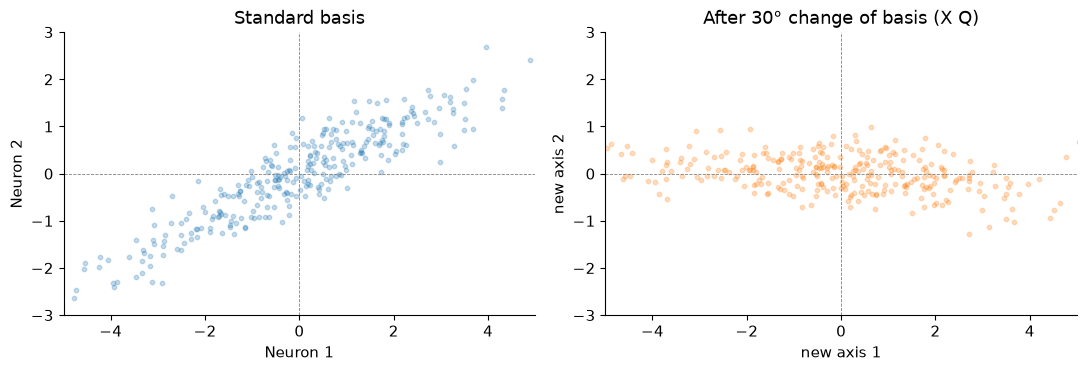

Total variance (standard basis): 5.0677
Total variance (rotated basis) : 5.0677


In [21]:
# --- A change of basis is a rotation of the coordinate axes
# Take the correlated 2-neuron data from Section 2 and rotate the axes by 30°.
theta = np.radians(30)
Q = np.array([[np.cos(theta), -np.sin(theta)],
              [np.sin(theta),  np.cos(theta)]])   # orthogonal: Q^T Q = I

print("Q^T Q = I ? ", np.allclose(Q.T @ Q, np.eye(2)))

# Express the data in the new (rotated) basis
X_new = X_centered @ Q       # shape (n, 2)

# The data cloud is the same shape — only the coordinate frame changed.
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

axes[0].scatter(X_centered[:, 0], X_centered[:, 1], alpha=0.25, s=10)
axes[0].set_title("Standard basis")
axes[0].set_xlabel("Neuron 1"); axes[0].set_ylabel("Neuron 2")

axes[1].scatter(X_new[:, 0], X_new[:, 1], alpha=0.25, s=10, color="C1")
axes[1].set_title("After 30° change of basis (X Q)")
axes[1].set_xlabel("new axis 1"); axes[1].set_ylabel("new axis 2")

for ax in axes:
    ax.axhline(0, color="gray", lw=0.6, ls="--")
    ax.axvline(0, color="gray", lw=0.6, ls="--")
    ax.set_xlim(-5, 5); ax.set_ylim(-3, 3); ax.set_aspect("equal")
plt.tight_layout(); plt.show()

# Trace of the covariance is unchanged (total variance is basis-invariant)
print("Total variance (standard basis):", np.trace(np.cov(X_centered, rowvar=False)).round(4))
print("Total variance (rotated basis) :", np.trace(np.cov(X_new,      rowvar=False)).round(4))


> **▶ Task 6.1 — 🧐 ⭐️⭐️ Diagonalize the $\Sigma$ by the rotation matrix $Q$.**
>
> Hint: Use the following equation to find the diagonalized matrix:
> $Q^\top\Sigma Q$.  
> What angles give you the most separated diagonal terms?

In [22]:
def rotate_and_sandwich(angle_deg=0.0):
    theta = np.radians(angle_deg)
    Q = np.array([[np.cos(theta), -np.sin(theta)],
                  [np.sin(theta),  np.cos(theta)]])   # orthogonal basis

    Lambda = Q.T @ Sigma @ Q
    print("Lambda: \n", Lambda)
_ = interact(rotate_and_sandwich, angle_deg = (0, 180, 1))

interactive(children=(IntSlider(value=0, description='angle_deg', max=180), Output()), _dom_classes=('widget-i…

> **✏️ Your answer (Task 6.1).**
>
> *At which angle(s) are the off-diagonal terms ~0 (data decorrelated)?*  … (double-click to edit)
>
> *How do those angles relate to the eigenvectors of Sigma?*  … (double-click to edit)


### One basis is special: the eigenbasis of the covariance matrix

An arbitrary rotation (like the 30° above) leaves the two coordinates **correlated** — the cloud still looks tilted. But there is exactly one orthogonal basis that removes the correlation: the **eigenbasis of the covariance matrix**, which we computed in Section 5.

When we use the eigenvectors $Q = [\mathbf{v}_1, \mathbf{v}_2]$ as our new basis, the covariance matrix becomes **diagonal** — the new coordinates are uncorrelated, and their variances are exactly the eigenvalues $\lambda_1, \lambda_2$. This is the diagonalization $\Sigma = Q \Lambda Q^\top$ from Section 5, seen from the data's point of view.

Let's verify this concretely.


Covariance in the eigenbasis (should be DIAGONAL):
 [[4.932  0.    ]
 [0.     0.1357]]

Off-diagonal (correlation between new coords): 0.0
Variances along new axes : [4.932  0.1357]
Eigenvalues (sorted)     : [4.932  0.1357]


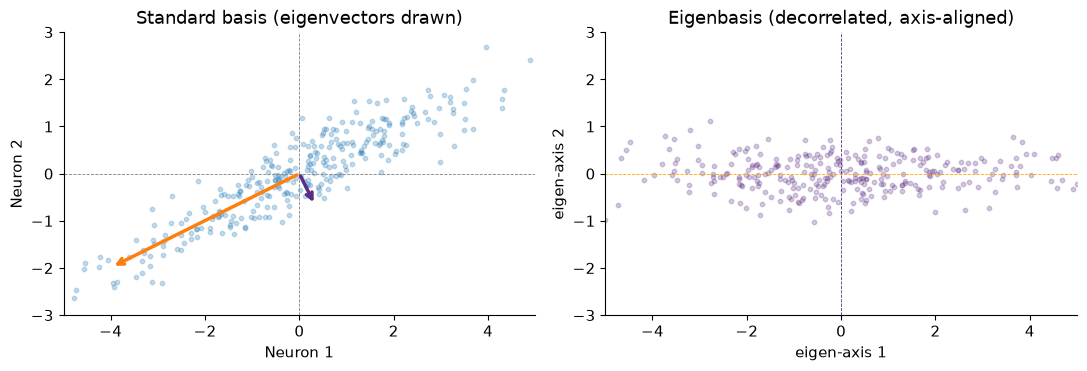

In [23]:
# --- Change into the eigenbasis of the covariance matrix
# vec_sorted holds the eigenvectors (columns), sorted by descending eigenvalue (Section 5).
X_eigenbasis = X_centered @ vec_sorted     # coordinates in the eigenbasis

cov_eigenbasis = np.cov(X_eigenbasis, rowvar=False)
print("Covariance in the eigenbasis (should be DIAGONAL):\n", cov_eigenbasis.round(4))
print("\nOff-diagonal (correlation between new coords):", cov_eigenbasis[0, 1].round(6))
print("Variances along new axes :", np.diag(cov_eigenbasis).round(4))
print("Eigenvalues (sorted)     :", lam_sorted.round(4))

# Visualise: in the eigenbasis the cloud is axis-aligned
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

axes[0].scatter(X_centered[:, 0], X_centered[:, 1], alpha=0.25, s=10)
for i in range(2):
    v = vec_sorted[:, i] * np.sqrt(lam_sorted[i]) * 2
    axes[0].annotate("", xy=v, xytext=[0, 0],
                     arrowprops=dict(arrowstyle="->", color=f"C{i+1}", lw=2.5))
axes[0].set_title("Standard basis (eigenvectors drawn)")
axes[0].set_xlabel("Neuron 1"); axes[0].set_ylabel("Neuron 2")
axes[0].axhline(0, color="gray", lw=0.6, ls="--")
axes[0].axvline(0, color="gray", lw=0.6, ls="--")

axes[1].scatter(X_eigenbasis[:, 0], X_eigenbasis[:, 1], alpha=0.25, s=10, color="C2")
axes[1].set_title("Eigenbasis (decorrelated, axis-aligned)")
axes[1].set_xlabel("eigen-axis 1"); axes[1].set_ylabel("eigen-axis 2")
axes[1].axhline(0, color="orange", lw=0.6, ls="--")
axes[1].axvline(0, color="C2", lw=0.6, ls="--")
for ax in axes:
    ax.set_xlim(-5, 5); ax.set_ylim(-3, 3); ax.set_aspect("equal")
plt.tight_layout(); plt.show()


In [24]:
# --- Interactive: rotate the coordinate axes and watch the projected variances
# Drag the slider to change the basis-rotation angle. The right panel shows the
# data in the rotated basis; the bar chart shows the variance captured by each
# new axis. The dashed line marks the total variance (invariant — Section 4).

total_var = np.trace(np.cov(X_centered, rowvar=False))   # basis-invariant

# angle (in degrees) that rotates the standard axes onto the eigenbasis,
# so students can "find" the decorrelating rotation by hand
eig_angle_deg = np.degrees(np.arctan2(vec_sorted[1, 0], vec_sorted[0, 0]))


def rotate_and_project(angle_deg=0.0):
    theta = np.radians(angle_deg)
    Q = np.array([[np.cos(theta), -np.sin(theta)],
                  [np.sin(theta),  np.cos(theta)]])   # orthogonal basis

    X_rot = X_centered @ Q                 # coordinates in the rotated basis
    cov_rot = np.cov(X_rot, rowvar=False)
    var1, var2 = np.diag(cov_rot)
    off = cov_rot[0, 1]

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    # (0) original data with the rotated axes drawn on top
    axes[0].scatter(X_centered[:, 0], X_centered[:, 1], alpha=0.25, s=10)
    for i, col in enumerate(["C1", "C2"]):
        axis_vec = Q[:, i] * 3.0
        axes[0].annotate("", xy=axis_vec, xytext=-axis_vec,
                         arrowprops=dict(arrowstyle="->", color=col, lw=2.5))
        axes[0].text(axis_vec[0] * 1.1, axis_vec[1] * 1.1, f"axis {i+1}", color=col)
    axes[0].set_title(f"Standard basis + rotated axes ({angle_deg:.0f}°)")
    axes[0].set_xlabel("Neuron 1"); axes[0].set_ylabel("Neuron 2")

    # (1) data expressed in the rotated basis
    axes[1].scatter(X_rot[:, 0], X_rot[:, 1], alpha=0.25, s=10, color="C2")
    axes[1].set_title(f"Rotated basis   (off-diag cov = {off:+.3f})")
    axes[1].set_xlabel("axis 1"); axes[1].set_ylabel("axis 2")

    for ax in axes[:2]:
        ax.axhline(0, color="gray", lw=0.6, ls="--")
        ax.axvline(0, color="gray", lw=0.6, ls="--")
        ax.set_xlim(-5, 5); ax.set_ylim(-5, 5); ax.set_aspect("equal")

    # (2) variance captured by each new axis
    axes[2].bar(["axis 1", "axis 2"], [var1, var2], color=["C1", "C2"], alpha=0.8)
    axes[2].axhline(total_var, color="gray", lw=1.0, ls="--",
                    label=f"total variance = {total_var:.3f}")
    axes[2].set_ylim(0, total_var * 1.1)
    axes[2].set_ylabel("projected variance")
    axes[2].set_title(f"var1={var1:.3f},  var2={var2:.3f},  sum={var1+var2:.3f}")
    axes[2].legend(loc="upper right", fontsize=9)

    plt.tight_layout(); plt.show()

    print(f"Angle = {angle_deg:.1f}°   |   off-diagonal covariance = {off:+.4f}")
    print(f"The eigenbasis (fully decorrelated) is at angle ≈ {eig_angle_deg:.1f}° "
          f"or {eig_angle_deg + 180:.1f}° — try to find where the off-diagonal hits 0 "
          f"and one bar is tallest.")


_ = interact(rotate_and_project,
             angle_deg=widgets.FloatSlider(min=-90, max=90, step=1, value=0,
                                           description="rotation °"))

interactive(children=(FloatSlider(value=0.0, description='rotation °', max=90.0, min=-90.0, step=1.0), Output(…

In [25]:
# --- Interactive: control BOTH the correlation of the data and the basis rotation
# Two sliders:
#   • correlation  — reshapes the data cloud (circle → cigar)
#   • rotation °   — rotates the coordinate axes
# The bar chart shows the variance captured by each new axis. The take-home:
# when correlation ≈ 0 the cloud is round, both bars stay equal for EVERY
# rotation, and there is no useful dimensionality reduction. As correlation
# grows, a single rotation angle concentrates almost all variance on one axis.

_VAR = 4.0        # equal marginal variance on both axes (so ρ=0 → a circle)
_N   = 300
_SEED = 0         # fixed seed: cloud shape is stable when only the angle changes


def make_data(rho):
    """Generate n zero-mean 2-D points with equal variance and correlation rho."""
    rng = np.random.default_rng(_SEED)
    cov = np.array([[_VAR,       rho * _VAR],
                    [rho * _VAR, _VAR      ]])
    L = np.linalg.cholesky(cov)
    X = rng.standard_normal((_N, 2)) @ L.T
    return X - X.mean(axis=0)


def rotate_project_correlate(correlation=0.8, angle_deg=0.0):
    Xc = make_data(correlation)
    total_var = np.trace(np.cov(Xc, rowvar=False))     # basis-invariant

    # eigenbasis of THIS cloud (the rotation that fully decorrelates it)
    lam, vec = np.linalg.eigh(np.cov(Xc, rowvar=False))
    order = np.argsort(lam)[::-1]
    lam, vec = lam[order], vec[:, order]
    eig_angle = np.degrees(np.arctan2(vec[1, 0], vec[0, 0]))
    best_ratio = lam[0] / lam.sum()                    # max achievable var fraction

    # rotate the coordinate axes by angle_deg
    theta = np.radians(angle_deg)
    Q = np.array([[np.cos(theta), -np.sin(theta)],
                  [np.sin(theta),  np.cos(theta)]])
    X_rot = Xc @ Q
    cov_rot = np.cov(X_rot, rowvar=False)
    var1, var2 = np.diag(cov_rot)
    off = cov_rot[0, 1]

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    # (0) original cloud + rotated axes
    axes[0].scatter(Xc[:, 0], Xc[:, 1], alpha=0.25, s=10)
    for i, col in enumerate(["C1", "C2"]):
        axis_vec = Q[:, i] * 3.5
        axes[0].annotate("", xy=axis_vec, xytext=-axis_vec,
                         arrowprops=dict(arrowstyle="->", color=col, lw=2.5))
        axes[0].text(axis_vec[0] * 1.1, axis_vec[1] * 1.1, f"axis {i+1}", color=col)
    axes[0].set_title(f"Data (ρ = {correlation:.2f}) + rotated axes ({angle_deg:.0f}°)")
    axes[0].set_xlabel("Neuron 1"); axes[0].set_ylabel("Neuron 2")

    # (1) data in the rotated basis
    axes[1].scatter(X_rot[:, 0], X_rot[:, 1], alpha=0.25, s=10, color="C2")
    axes[1].set_title(f"Rotated basis   (off-diag cov = {off:+.3f})")
    axes[1].set_xlabel("axis 1"); axes[1].set_ylabel("axis 2")

    for ax in axes[:2]:
        ax.axhline(0, color="gray", lw=0.6, ls="--")
        ax.axvline(0, color="gray", lw=0.6, ls="--")
        ax.set_xlim(-7, 7); ax.set_ylim(-7, 7); ax.set_aspect("equal")

    # (2) variance captured by each new axis
    axes[2].bar(["axis 1", "axis 2"], [var1, var2], color=["C1", "C2"], alpha=0.8)
    axes[2].axhline(total_var, color="gray", lw=1.0, ls="--",
                    label=f"total variance = {total_var:.2f}")
    axes[2].set_ylim(0, total_var * 1.1)
    axes[2].set_ylabel("projected variance")
    cur_ratio = max(var1, var2) / total_var
    axes[2].set_title(f"tallest axis keeps {cur_ratio:.0%} of variance "
                      f"(best possible: {best_ratio:.0%})")
    axes[2].legend(loc="upper right", fontsize=9)

    plt.tight_layout(); plt.show()

    if best_ratio < 0.6:
        verdict = ("→ Cloud is nearly round: NO rotation concentrates the variance, "
                   "so reducing to one axis would throw away ~half the information. "
                   "Dimensionality reduction is not useful here.")
    else:
        verdict = (f"→ Elongated cloud: at the eigenbasis angle (≈ {eig_angle:.0f}°) a "
                   f"single axis keeps {best_ratio:.0%} of the variance — reduction IS useful.")
    print(f"correlation ρ = {correlation:+.2f}   |   off-diagonal cov = {off:+.3f}")
    print(verdict)


_ = interact(
    rotate_project_correlate,
    correlation=widgets.FloatSlider(min=-0.95, max=0.95, step=0.05, value=0.8,
                                    description="correlation"),
    angle_deg=widgets.FloatSlider(min=-90, max=90, step=1, value=0,
                                  description="rotation °"),
)

interactive(children=(FloatSlider(value=0.8, description='correlation', max=0.95, min=-0.95, step=0.05), Float…

> **▶ Task 6.2 — 🧐 ⭐️⭐️ Basis change preserves geometry.**
>
> An orthogonal change of basis is a rigid rotation: it preserves vector lengths and the angles between vectors. Verify this numerically.
>
> 1. Take the first two data points `p = X_centered[0]` and `q = X_centered[1]`.
> 2. Rotate them into the eigenbasis: `p_new = vec_sorted.T @ p`, likewise for `q`.
> 3. Check that the **norms** are preserved: `||p|| == ||p_new||`.
> 4. Check that the **inner product** (hence the angle) is preserved: `p · q == p_new · q_new`.
>
> These invariances are *why* PCA can rotate the data into a nicer coordinate system without distorting it — the topic of next week's session.


In [26]:
# TODO 6.2 — verify that an orthogonal basis change preserves norms and inner products
p = X_centered[0]
q = X_centered[1]

# Rotate into the eigenbasis
p_new = ___   # YOUR CODE HERE
q_new = ___   # YOUR CODE HERE

# Norms preserved?
# YOUR CODE HERE
# YOUR CODE HERE
# YOUR CODE HERE

# Inner product (and hence angle) preserved?
# YOUR CODE HERE
# YOUR CODE HERE
# YOUR CODE HERE


<a id="section-7"></a>
## 7. Looking ahead: from diagonalization to PCA

Everything in this notebook has been building, quietly, towards a single powerful idea that next week's session develops in full — **Principal Component Analysis (PCA)**.

Here is the through-line, in the language you now have:

1. **Covariance matrix** (Section 2): the symmetric matrix $\Sigma = \tfrac{1}{n-1}X^\top X$ that captures how variables co-vary.
2. **Eigendecomposition** (Section 5): because $\Sigma$ is symmetric, it diagonalizes as $\Sigma = Q\Lambda Q^\top$ with orthogonal eigenvectors and real, non-negative eigenvalues.
3. **Change of basis** (Section 6): projecting the data onto those eigenvectors, $X_{\text{eig}} = XQ$, gives new coordinates that are **uncorrelated**, with variance $\lambda_i$ along the $i$-th axis.

**That is PCA.** The eigenvectors of the covariance matrix are the *principal components*; the eigenvalues are the *variance explained* by each one. Ordering them from largest to smallest eigenvalue and keeping only the first few is **dimensionality reduction** — a way to summarise high-dimensional data (many neurons, many EEG channels, many voxels) with a handful of numbers.

Next week we will:
- introduce the **Singular Value Decomposition (SVD)**, the numerically robust way to compute PCA directly from the data matrix $X$ without forming $\Sigma$;
- apply PCA to a **real neural / EEG dataset** and see how a few components capture the dominant structure;
- use the components for visualization, denoising, and decoding.

> **▶ Optional teaser — 😎 ⭐️⭐️⭐️ (no answer expected yet).**
>
> The eigenvalues you computed in Section 5 tell you how much variance lives along each eigen-axis. Compute the fraction $\lambda_1 / (\lambda_1 + \lambda_2)$ for our 2-neuron dataset. If you had to describe each trial with a *single* number instead of two, this is the fraction of the total variance you would keep by using only the first principal component. Hold that thought for next week.


In [27]:
# Optional teaser — fraction of variance along the leading eigen-axis
frac_pc1 = lam_sorted[0] / lam_sorted.sum()
print(f"Variance along eigen-axis 1: {lam_sorted[0]:.3f}")
print(f"Variance along eigen-axis 2: {lam_sorted[1]:.3f}")
print(f"Fraction kept by PC1 alone : {frac_pc1:.1%}")
print("\n→ Next week we'll call this the 'explained variance ratio' of PC1.")


Variance along eigen-axis 1: 4.932
Variance along eigen-axis 2: 0.136
Fraction kept by PC1 alone : 97.3%

→ Next week we'll call this the 'explained variance ratio' of PC1.


<a id="section-8"></a>
## 8. Lego-style exercises

These exercises consolidate the *mathematics* of this session. They increase in difficulty.


### Exercise 8.1 — 👨🏻‍🏫 ⭐️ Eigenvalues of a diagonal matrix

For a **diagonal matrix**, the eigenvalues are just the diagonal entries and the eigenvectors are the standard basis vectors.

1. Create `D = np.diag([5.0, 2.0, 0.5])`.
2. Compute `eigvals, eigvecs = np.linalg.eigh(D)` and print both.
3. Verify numerically that each eigenvector satisfies `D @ v == lambda * v`.
4. Do the eigenvectors equal the standard basis vectors $e_1, e_2, e_3$? Why does this make sense geometrically?


In [28]:
# TODO 8.1 — eigenvalues of a diagonal matrix
D = np.diag([5.0, 2.0, 0.5])

eigvals_D, eigvecs_D = ___   # YOUR CODE HERE
# YOUR CODE HERE
# YOUR CODE HERE

# YOUR CODE HERE
    v = ___   # YOUR CODE HERE
    lam = ___   # YOUR CODE HERE
    # YOUR CODE HERE


IndentationError: unexpected indent (2465727370.py, line 9)

### Exercise 8.2 — 🧐 ⭐️⭐️ OLS with multiple predictors

You want to predict the firing rate of one neuron from the firing rates of three others (a simple linear model of functional connectivity).

1. Simulate a design matrix `X_fc` of shape `(200, 3)` (three predictor neurons, 200 trials).
2. Generate a target `y_fc` as a linear combination with known weights `[0.8, -0.5, 0.2]` plus Gaussian noise.
3. Recover the weights using `np.linalg.lstsq`.
4. Report the R² and compare recovered vs true weights.
5. **Bonus:** what happens to the recovered weights if two of the predictor columns are nearly identical? (Try `X_fc[:, 1] = X_fc[:, 0] + small_noise` and look at the recovered weights and the condition number `np.linalg.cond(X_fc)`.)


In [29]:
# TODO 8.2 — multi-predictor OLS
rng82 = np.random.default_rng(100)
n_obs_82 = 200

X_fc = rng82.standard_normal((n_obs_82, 3))
beta_true_82 = np.array([0.8, -0.5, 0.2])
y_fc = ___   # YOUR CODE HERE

beta_hat_82, _, _, _ = ___   # YOUR CODE HERE
print("True weights     :", beta_true_82)
print("Estimated weights:", beta_hat_82.round(3))

y_hat_82 = ___   # YOUR CODE HERE
ss_res_82 = ___   # YOUR CODE HERE
ss_tot_82 = ___   # YOUR CODE HERE
R2_82 = ___   # YOUR CODE HERE
print(f"R² = {R2_82:.3f}")


ValueError: not enough values to unpack (expected 4, got 0)

### Exercise 8.3 — 😎 ⭐️⭐️⭐️ Whitening: build a decorrelating transform

Diagonalizing the covariance matrix lets us **whiten** data — transform it so that the new covariance is the identity (unit variance, zero correlation). Whitening is a standard preprocessing step before many analyses, and it is a direct application of everything in this notebook.

The whitening transform is $W = \Lambda^{-1/2} Q^\top$, so that $\mathbf{z} = W\mathbf{x}$ has covariance $I$.

1. Using the 2-neuron data `X_centered`, its eigenvalues `lam_sorted` and eigenvectors `vec_sorted`, build $\Lambda^{-1/2}$ as `np.diag(1/np.sqrt(lam_sorted))`.
2. Form the whitening matrix `W = Lambda_inv_sqrt @ vec_sorted.T`.
3. Apply it: `Z = X_centered @ W.T`.
4. Verify that `np.cov(Z, rowvar=False)` is (approximately) the identity matrix.
5. Plot the whitened data — it should look like an isotropic (circular) cloud.
6. **Interpret:** why is the covariance of the whitened data the identity, in terms of the diagonalization $\Sigma = Q\Lambda Q^\top$?


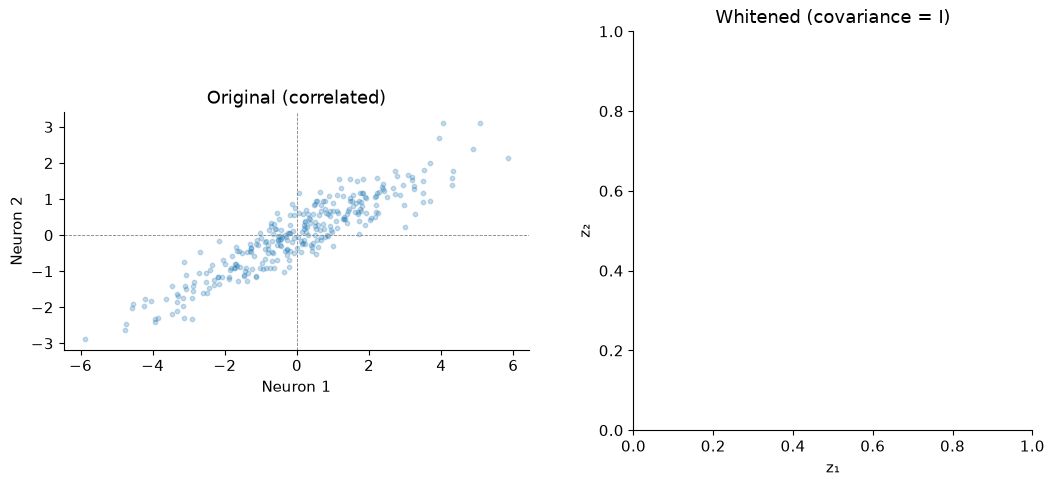

In [30]:
# TODO 8.3 — whitening transform

# 1-2. Build the whitening matrix W = Lambda^{-1/2} Q^T
Lambda_inv_sqrt = ___   # YOUR CODE HERE
W = ___   # YOUR CODE HERE

# 3. Apply it
Z = ___   # YOUR CODE HERE

# 4. Covariance should be the identity
# YOUR CODE HERE

# 5. Plot
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
axes[0].scatter(X_centered[:, 0], X_centered[:, 1], alpha=0.25, s=10)
axes[0].set_title("Original (correlated)")
axes[0].set_xlabel("Neuron 1"); axes[0].set_ylabel("Neuron 2")
# YOUR CODE HERE
axes[1].set_title("Whitened (covariance = I)")
axes[1].set_xlabel("z₁"); axes[1].set_ylabel("z₂")
for ax in axes:
    ax.axhline(0, color="gray", lw=0.6, ls="--")
    ax.axvline(0, color="gray", lw=0.6, ls="--")
    ax.set_aspect("equal")
plt.tight_layout(); plt.show()

<a id="section-9"></a>
## 9. Covariance and regression on real EEG data

The covariance matrix is the first thing you compute on any multichannel recording. Here we load 16-channel EEG from one subject of a classic resting-state dataset, recorded in two conditions: **eyes closed** and
**eyes open**.

The channels are ordered from **frontal** (top-left) to **posterior** (bottom-right).
With the eyes closed, the brain produces a strong ~10 Hz *alpha rhythm* over the
posterior (occipital/parietal) electrodes — the **Berger effect**. Because neighbouring
posterior channels pick up the *same* rhythm, they **co-vary**: the bottom-right block of
the covariance matrix should light up with the eyes closed and fade with the eyes open.

Watch for two things: (1) the manual matrix formula $\frac{1}{n-1}X^\top X$ gives exactly
the same answer as `np.cov`, on real data; (2) the **spatial structure** of the covariance
matrix carries real physiological meaning. Next week we will ask what the *dominant
directions* of this covariance are — which is where PCA begins.

> **Data note.** This section loads two small CSV files (`data/eeg_cov_eyes_closed.csv` and `data/eeg_cov_eyes_open.csv`) that were prepared, once, by `build_eeg_covariance_data.py` from the *EEG Alpha Waves* dataset (Cattan, Rodrigues & Congedo, 2017). All the EEG preprocessing — DC-offset removal, channel ordering, subsampling — lives in that script, so here we only ever call `pd.read_csv` and `np.cov`.

Eyes-closed matrix shape: (3000, 9) (samples x channels)
Manual XᵀX/(n-1) == np.cov : True


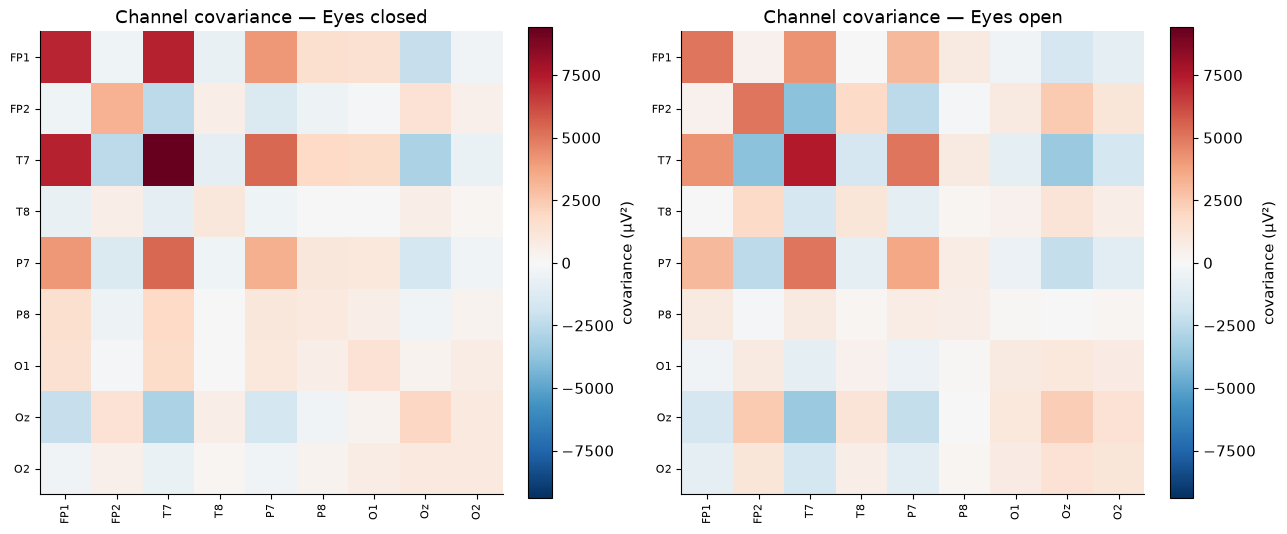


Mean posterior variance  — eyes closed: 1714 µV²
Mean posterior variance  — eyes open  : 1709 µV²

Total variance (trace) — closed: 29501 µV²   open: 27202 µV²


In [31]:
# --- Covariance in matrix form, on real EEG data
# Two conditions from one subject of the EEG Alpha Waves dataset
# (Cattan, Rodrigues & Congedo, 2018). Each file is a (samples x 16 channels)
# matrix, already detrended by the data-prep script — we only compute covariance.
eeg_closed = pd.read_csv("data/eeg_cov_eyes_closed.csv", index_col=0)
eeg_open   = pd.read_csv("data/eeg_cov_eyes_open.csv",   index_col=0)
ch_names   = list(eeg_closed.columns)   # frontal -> posterior order

print("Eyes-closed matrix shape:", eeg_closed.shape, "(samples x channels)")

# The same matrix formula from earlier in this section, now on real data:
Xc = eeg_closed.values
Xc_centered = Xc - Xc.mean(axis=0)
cov_manual = Xc_centered.T @ Xc_centered / (len(Xc) - 1)
print("Manual XᵀX/(n-1) == np.cov :", np.allclose(cov_manual, np.cov(Xc, rowvar=False)))

# Covariance matrix per condition (16 x 16)
cov_closed = np.cov(eeg_closed.values, rowvar=False)
cov_open   = np.cov(eeg_open.values,   rowvar=False)

# Shared colour scale so the two conditions are directly comparable
vmax = max(np.abs(cov_closed).max(), np.abs(cov_open).max())

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
for ax, cov, title in [(axes[0], cov_closed, "Eyes closed"),
                       (axes[1], cov_open,   "Eyes open")]:
    im = ax.imshow(cov, cmap="RdBu_r", vmin=-vmax, vmax=vmax)
    ax.set_xticks(range(len(ch_names))); ax.set_xticklabels(ch_names, rotation=90, fontsize=8)
    ax.set_yticks(range(len(ch_names))); ax.set_yticklabels(ch_names, fontsize=8)
    ax.set_title(f"Channel covariance — {title}")
    fig.colorbar(im, ax=ax, fraction=0.046, label="covariance (µV²)")
plt.tight_layout(); plt.show()

# The posterior (occipital/parietal) channels are the last few in our ordering
posterior = ["P7", "P8", "O1", "Oz", "O2"]
pidx = [ch_names.index(c) for c in posterior]
print(f"\nMean posterior variance  — eyes closed: {np.mean([cov_closed[i,i] for i in pidx]):.0f} µV²")
print(f"Mean posterior variance  — eyes open  : {np.mean([cov_open[i,i]   for i in pidx]):.0f} µV²")
print("\nTotal variance (trace) — closed:", f"{np.trace(cov_closed):.0f} µV²",
      "  open:", f"{np.trace(cov_open):.0f} µV²")

### OLS on real data: predicting one EEG channel from the others

The matrix machinery above — $\hat{\boldsymbol\beta} = (X^\top X)^{-1}X^\top \mathbf{y}$, the
hat matrix, $R^2$ — is exactly what you use on real recordings. Here is a concrete
question we can pose on the EEG data: **how well can we predict the signal at one
electrode from all the others, at each moment in time?**

We take the occipital channel **Oz** as the target $\mathbf{y}$ and the other 15 channels
as the design matrix $X$ (plus an intercept). The fitted weights $\hat{\boldsymbol\beta}$
tell us which channels carry information about Oz. Because the eyes-closed alpha rhythm is
shared across neighbouring posterior electrodes, we expect **O1, O2, P7, P8** to receive
the largest weights — the same posterior structure we saw in the covariance matrix, now
seen through the lens of prediction.

Predicting Oz from the other 8 channels:
  R² (eyes closed) = 0.905
  R² (eyes open)   = 0.960


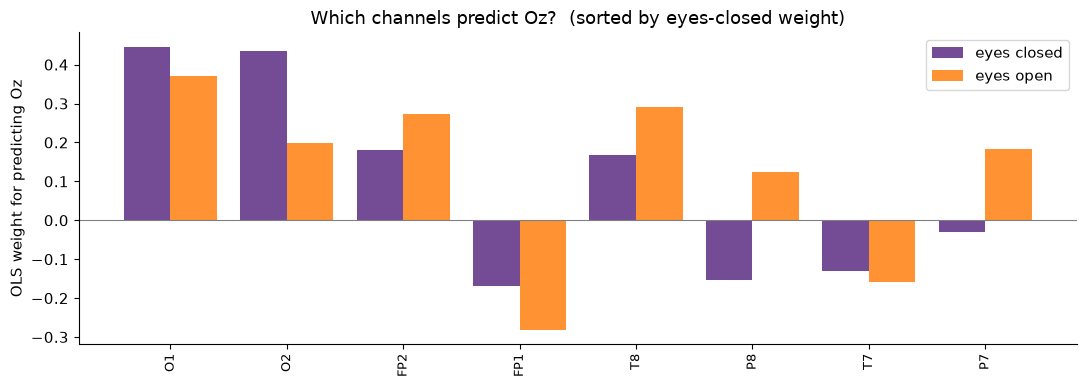


Sum of |weights| on posterior neighbours ['O1', 'O2', 'P7', 'P8']:
  eyes closed: 1.06
  eyes open  : 0.88
→ With eyes closed, the shared posterior alpha makes O1/O2/P7/P8 strong predictors;
  with eyes open that shared rhythm is gone, so their weights shrink.


In [32]:
# --- OLS in matrix form on real EEG: predict Oz from the other 15 channels
# eeg_closed = pd.read_csv("data/eeg_cov_eyes_closed.csv", index_col=0)
# eeg_open   = pd.read_csv("data/eeg_cov_eyes_open.csv",   index_col=0)
ch_names   = list(eeg_closed.columns)

TARGET     = "Oz"
predictors = [c for c in ch_names if c != TARGET]

def fit_channel_ols(df, target, predictors):
    """OLS predicting `target` from `predictors` (+ intercept). Returns weights, R²."""
    y = df[target].values
    X = np.column_stack([np.ones(len(df)), df[predictors].values])   # intercept + 15 channels
    beta, _, _, _ = np.linalg.lstsq(X, y, rcond=None)                # β = (XᵀX)⁻¹Xᵀy
    y_hat  = X @ beta
    ss_res = np.sum((y - y_hat) ** 2)
    ss_tot = np.sum((y - y.mean()) ** 2)
    return beta, y_hat, 1 - ss_res / ss_tot

beta_c, yhat_c, R2_c = fit_channel_ols(eeg_closed, TARGET, predictors)
beta_o, yhat_o, R2_o = fit_channel_ols(eeg_open,   TARGET, predictors)

print(f"Predicting {TARGET} from the other {len(predictors)} channels:")
print(f"  R² (eyes closed) = {R2_c:.3f}")
print(f"  R² (eyes open)   = {R2_o:.3f}")

# --- Visualise the fitted weights (drop the intercept, keep the 15 channel weights)
w_closed = beta_c[1:]
w_open   = beta_o[1:]
order    = np.argsort(np.abs(w_closed))[::-1]   # sort by importance in eyes-closed

fig, ax = plt.subplots(figsize=(11, 4))
x = np.arange(len(predictors))
ax.bar(x - 0.2, w_closed[order], width=0.4, label="eyes closed", color="#5b2c83", alpha=0.85)
ax.bar(x + 0.2, w_open[order],   width=0.4, label="eyes open",   color="#ff7f0e", alpha=0.85)
ax.axhline(0, color="gray", lw=0.8)
ax.set_xticks(x); ax.set_xticklabels([predictors[i] for i in order], rotation=90, fontsize=9)
ax.set_ylabel(f"OLS weight for predicting {TARGET}")
ax.set_title(f"Which channels predict {TARGET}?  (sorted by eyes-closed weight)")
ax.legend()
plt.tight_layout(); plt.show()

# --- The posterior neighbours carry the shared alpha; quantify it
posterior = [c for c in ["O1", "O2", "P7", "P8"] if c in predictors]
post_idx  = [predictors.index(c) for c in posterior]
print(f"\nSum of |weights| on posterior neighbours {posterior}:")
print(f"  eyes closed: {np.abs(w_closed[post_idx]).sum():.2f}")
print(f"  eyes open  : {np.abs(w_open[post_idx]).sum():.2f}")
print("→ With eyes closed, the shared posterior alpha makes O1/O2/P7/P8 strong predictors;")
print("  with eyes open that shared rhythm is gone, so their weights shrink.")

## About this notebook

**Course:** Quantitative Methods in Neuroscience, Master in Neuroscience, University of Geneva (2026-27)  
**Instructor:** Prof. Sami El-Boustani  
**Corresponding TAs:** Nosrat Mohammadi, Jonathan Wirsich & Caroline Lourencoalves  
**Week 10:** Linear Algebra for Statistics

This session focuses on the *mathematics* that underpins multivariate statistics: covariance in matrix form, regression as projection, trace/determinant as invariants, eigendecomposition, and change of basis. It deliberately stops at the threshold of **Principal Component Analysis**, which is developed in full — with a real dataset — in **Notebook 11**.

Most datasets in this notebook are small and synthetic, generated in-notebook so that every student obtains identical, reproducible numbers. **Section 9** additionally uses a small, real EEG dataset (see the data note in that section).

**Section 9 data.** The EEG covariance/regression demo uses the *EEG Alpha Waves* dataset (Cattan, Rodrigues & Congedo, GIPSA-lab 2017; Zenodo record 2348892). The two CSV files it loads (`data/eeg_cov_eyes_closed.csv`, `data/eeg_cov_eyes_open.csv`) are produced by the preprocessing script `build_eeg_covariance_data.py` — run it once before distributing the notebook. If those files are absent, Section 9 will not run, but the rest of the notebook is fully self-contained.

For feedback or questions, use the course GPT bot: https://chatgpt.com/g/g-69fc9bfc9a748191a912a124800d9254-qmn-teaching-assistant-bot
